# 207. Course Schedule

## Problem Statement

There are a total of `numCourses` courses you have to take, labeled from `0` to `numCourses - 1`. You are given an array `prerequisites` where `prerequisites[i] = [ai, bi]` indicates that you must take course $b_i$ first if you want to take course $a_i$.

For example, the pair `[0, 1]` indicates that to take course `0` you have to first take course `1`.

Return `true` if you can finish all courses. Otherwise, return `false`.

---

### Examples

#### Example 1
* **Input:** `numCourses = 2`, `prerequisites = [[1,0]]`
* **Output:** `true`
* **Explanation:** There are a total of 2 courses to take. To take course 1 you should have finished course 0. So it is possible.

#### Example 2
* **Input:** `numCourses = 2`, `prerequisites = [[1,0],[0,1]]`
* **Output:** `false`
* **Explanation:** There are a total of 2 courses to take. To take course 1 you should have finished course 0, and to take course 0 you should also have finished course 1. So it is impossible.

---

### Constraints
* $1 \le \text{numCourses} \le 2000$
* $0 \le \text{prerequisites.length} \le 5000$
* $\text{prerequisites}[i].\text{length} == 2$
* $0 \le a_i, b_i < \text{numCourses}$
* All the pairs `prerequisites[i]` are unique.

---

## Optimal Solution (Kahn's Algorithm / BFS Topological Sort)

### Intuition & Approach
This problem can be modeled as finding whether a **Directed Graph** contains a cycle. Each course is a node, and a prerequisite requirement `[a, b]` (meaning $b \to a$) represents a directed edge from course $b$ to course $a$.

1. **In-Degree Array & Adjacency List:**  
   Build an adjacency list representation of the graph and track the **in-degree** (number of incoming edges / prerequisites required) for each course.

2. **Kahn's Algorithm (BFS):**  
   - Push all courses with an in-degree of `0` (courses with no prerequisites) into a BFS queue.
   - Process courses from the queue one by one:
     - Increment a `completed_courses` counter.
     - For each course $neighbor$ dependent on the current course, decrement its in-degree by 1.
     - If its in-degree becomes `0`, push it to the queue.

3. **Cycle Detection Check:**  
   If `completed_courses == numCourses`, return `true` (it's a Directed Acyclic Graph). Otherwise, return `false` (a cycle prevents all courses from being completed).



#### Using Kahn's Algorithm (BFS)

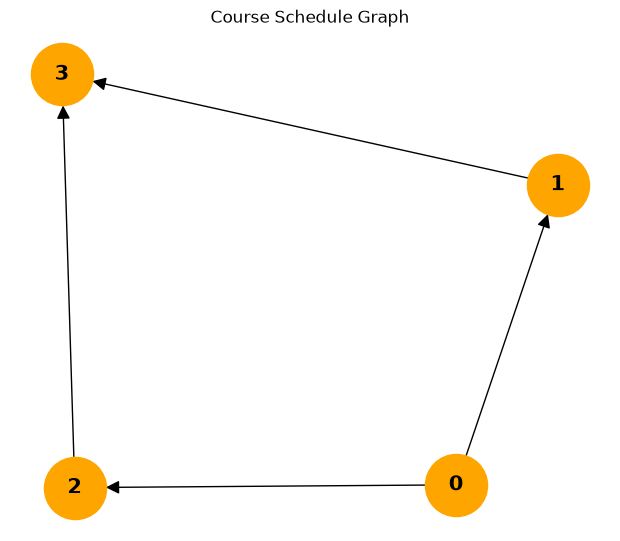

In [15]:
# this is a visualization of the course schedule graph using networkx and matplotlib

import networkx as nx
import matplotlib.pyplot as plt

numCourses = 4

prerequisites = [
    [1, 0],
    [2, 0],
    [3, 1],
    [3, 2]
]

graph = nx.DiGraph()

# Add all courses
for i in range(numCourses):
    graph.add_node(i)

# Add edges
for course, prerequisite in prerequisites:
    graph.add_edge(prerequisite, course)

# Draw graph
plt.figure(figsize=(6, 5))

pos = nx.spring_layout(graph, seed=42)

nx.draw(
    graph,
    pos,
    with_labels=True,
    node_size=2000,
    node_color="orange",
    arrows=True,
    arrowsize=20,
    font_size=15,
    font_weight="bold"
)

plt.title("Course Schedule Graph")
plt.show()

In [1]:
class Solution:
    def canFinish(self, numCourses: int, prerequisites: list[list[int]]) -> bool:
        grapgh = [[] for _ in range(numCourses)]
        indegree = [0] * numCourses
        
        for pair in prerequisites:
            course = pair[0]
            prereq = pair[1]
            grapgh[prereq].append(course)
            indegree[course] += 1
            
        queue = []
        for i in range(numCourses):
            if indegree[i] == 0:
                queue.append(i)
                
        count = 0
        while queue:
            current = queue.pop(0)
            count += 1
            for neighbor in grapgh[current]:
                indegree[neighbor] -= 1
                if indegree[neighbor] == 0:
                    queue.append(neighbor)
                    
        return count == numCourses
        

In [2]:
solution = Solution()
result = solution.canFinish(2, [[1, 0], [0, 1]])
print(result)  # Output: False

False


In [3]:
solution = Solution()
result = solution.canFinish(2, [[1, 0]])
print(result)  # Output: True

True


In [4]:
solution = Solution()
result = solution.canFinish(2, [[1, 0],[0, 1], [1, 0], [0, 1]])
print(result)  # Output: False

False


#### Brute Force Approach (DFS method)

In [5]:
class Solution:
    def canFinish(self, numCourses: int, prerequisites: list[list[int]]) -> bool:
        graph = {i: [] for i in range(numCourses)}
        for course, prereq in prerequisites:
            graph[course].append(prereq)

        visited = set()
        recStack = set()

        def dfs(course):
            if course in recStack:
                return False
            if course in visited:
                return True

            visited.add(course)
            recStack.add(course)

            for prereq in graph[course]:
                if not dfs(prereq):
                    return False

            recStack.remove(course)
            return True

        for course in range(numCourses):
            if not dfs(course):
                return False

        return True

In [6]:
solution = Solution()
result = solution.canFinish(2, [[1, 0]])
print(result)  # Output: True

True


### Complexity
* **Time Complexity:** $\mathcal{O}(V + E)$ — Where $V = \text{numCourses}$ and $E = \text{prerequisites.length}$. Every vertex and edge is processed at most once.
* **Space Complexity:** $\mathcal{O}(V + E)$ — To build the adjacency list, in-degree array, and queue.
